# Phase 8: adversarial local search around CM champions

This notebook checks whether a space-filling or Bayesian optimizer can find a fixed-radius deformation whose relative systole exceeds a selected CM baseline. It reads the frozen Phase-8 ledgers; set `REGENERATE=True` below to rerun all 2,400 exact evaluations.

In [1]:
from pathlib import Path
import gzip, json, os, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
CANDIDATES = (HERE, HERE.parent, HERE / 'passive-cliffords')
PROJECT = next(path for path in CANDIDATES if (path / 'src' / 'gkp_passive_cliffords').exists())
sys.path[:0] = [str(PROJECT / 'src'), str(PROJECT.parent / 'src')]
DATA = PROJECT / 'data'
FIGURES = PROJECT / 'figures'
FIGURES.mkdir(exist_ok=True)
REGENERATE = False
if REGENERATE:
    subprocess.run([sys.executable, str(PROJECT / 'scripts/generate_phase8_adversarial_search.py')], check=True, cwd=PROJECT)
    subprocess.run([sys.executable, str(PROJECT / 'scripts/audit_phase8_precision.py')], check=True, cwd=PROJECT)
print('Project:', PROJECT.name)

Project: passive-cliffords


## What is being optimized?

For a CM metric $G_0$ and fixed intrinsic radius $r$, we seek

$$M_{X_0}(r)=\max_{d_{\rm RMS}(G_0,G)=r}\frac{\ell^2(G)}{\ell^2(G_0)}.$$

A value above one is a counterexample to local maximality at that radius. The tangent directions come from $K^TA+AK=0$, with metric tangent $\dot G=K^TG+GK$. Null rotations are removed, leaving $g(g+1)$ effective coordinates.

In [2]:
def load_json(name):
    path = DATA / name
    if path.exists(): return json.loads(path.read_text())
    with gzip.open(str(path) + '.gz', 'rt') as handle: return json.load(handle)
summary = pd.DataFrame(load_json('phase8_adversarial_search_summary.json'))
evaluations = pd.DataFrame(load_json('phase8_adversarial_search_evaluations.json'))
protocol = load_json('phase8_adversarial_protocol.json')
audits = pd.DataFrame(load_json('phase8_high_precision_audit.json'))
summary['type'] = summary['polarization_type'].apply(lambda x: '(' + ','.join(map(str, x)) + ')')
evaluations['type'] = evaluations['polarization_type'].apply(lambda x: '(' + ','.join(map(str, x)) + ')')
print(f"{len(summary)} searches, {len(evaluations)} exact ell^2 evaluations")
pd.Series({
    'radii': protocol['radii'],
    'Sobol budget/search': protocol['sobol_budget'],
    'Bayesian budget/search': protocol['bayesian_budget'],
    'surrogate': protocol['surrogate'],
    'acquisition': protocol['acquisition'],
})

25 searches, 2400 exact ell^2 evaluations


radii                                        [0.005, 0.01, 0.02, 0.05, 0.1]
Sobol budget/search                                                      64
Bayesian budget/search                                                   64
surrogate                 fixed Matern-5/2 Gaussian process, length scal...
acquisition                   UCB mean + 2.0 * posterior standard deviation
dtype: object

## Selected CM champions

One highest-$\ell^2$ Phase-5 record is selected per type. Ties prefer the larger passive logical image, then a stable candidate ID.

In [3]:
champions = (summary.sort_values(['type','radius']).groupby('type', as_index=False).first())
champions[['type','dimension_g','cm_ell_squared','cm_logical_image_order','generic_minimal_image_order','tangent_dimension','candidate_id']]

,type,dimension_g,cm_ell_squared,cm_logical_image_order,generic_minimal_image_order,tangent_dimension,candidate_id
0,"(1,1,2)",3,1.000000,6,1,12,g3_type_1_1_2_delta_m4_h_1_2_2_0_0_0_0_m1_m1
1,"(1,1,3)",3,1.154701,24,2,12,g3_type_1_1_3_delta_m3_h_2_2_2_m1_0_m1_0_0_1
2,"(1,2,2)",3,1.000000,48,1,12,g3_type_1_2_2_delta_m4_h_2_2_3_0_0_m1_m1_m1_m1
3,"(1,3)",2,0.816497,24,2,6,g2_type_1_3_delta_m24_h_6_6_3_2
4,"(1,5)",2,0.539360,4,2,6,g2_type_1_5_delta_m55_h_15_15_2_m4


## Headline search results

Both arms get 64 queries. They share 32 initial Sobol evaluations; pure Sobol gets 32 held-out directions, while Bayesian optimization gets 32 GP/UCB-selected directions.

In [4]:
by_radius = summary.groupby('radius').agg(
    mean_best_sobol_ratio=('sobol_best_ratio','mean'),
    mean_best_bayesian_ratio=('bayesian_best_ratio','mean'),
    closest_ratio_found=('overall_best_ratio','max'),
    counterexamples=('counterexample_found','sum'),
).reset_index()
display(by_radius.style.format({c:'{:.9f}' for c in by_radius.columns if 'ratio' in c}))
bo_wins = int((summary.bayesian_best_ratio > summary.sobol_best_ratio + 1e-12).sum())
ties = int((np.abs(summary.bayesian_best_ratio-summary.sobol_best_ratio) <= 1e-12).sum())
print(f'Bayesian beats Sobol in {bo_wins}/25 searches; ties in {ties}/25.')
print('Counterexamples found:', int(summary.counterexample_found.sum()))
print('Closest ratio:', summary.overall_best_ratio.max())

,radius,mean_best_sobol_ratio,mean_best_bayesian_ratio,closest_ratio_found,counterexamples
0,0.005000,0.997159352,0.997506412,0.999021793,0
1,0.010000,0.994644545,0.995358795,0.998993350,0
2,0.020000,0.989096382,0.989536155,0.994568608,0
3,0.050000,0.972262314,0.975656883,0.991763955,0
4,0.100000,0.946106513,0.959611138,0.992069171,0


Bayesian beats Sobol in 19/25 searches; ties in 3/25.
Counterexamples found: 0
Closest ratio: 0.999021792564747


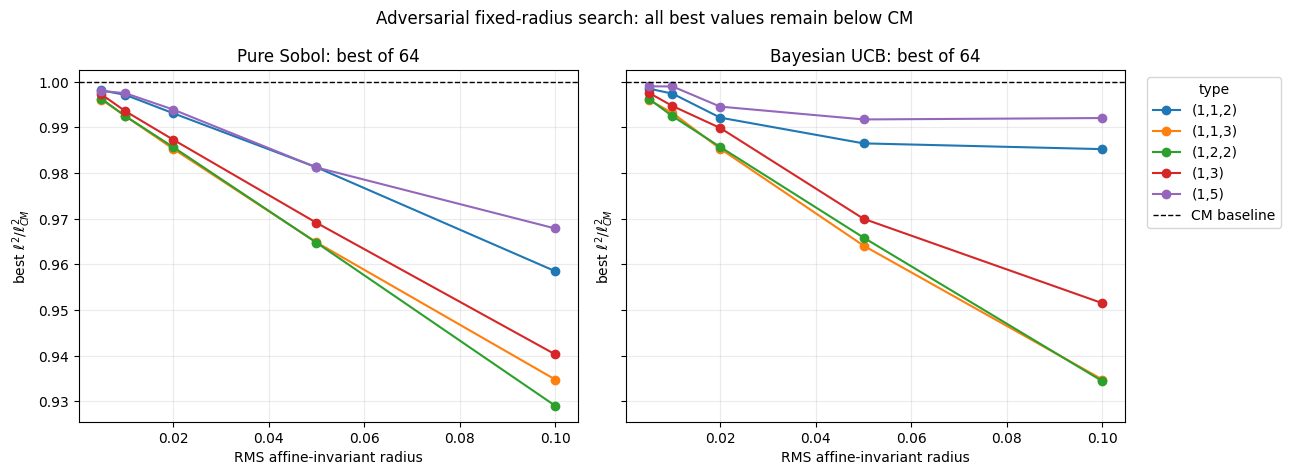

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for label, group in summary.groupby('type'):
    group = group.sort_values('radius')
    axes[0].plot(group.radius, group.sobol_best_ratio, marker='o', label=label)
    axes[1].plot(group.radius, group.bayesian_best_ratio, marker='o', label=label)
for ax, title in zip(axes, ['Pure Sobol: best of 64', 'Bayesian UCB: best of 64']):
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='CM baseline')
    ax.set(title=title, xlabel='RMS affine-invariant radius', ylabel=r'best $\ell^2/\ell^2_{CM}$')
    ax.grid(alpha=.25)
axes[1].legend(title='type', bbox_to_anchor=(1.03, 1), loc='upper left')
fig.suptitle('Adversarial fixed-radius search: all best values remain below CM')
fig.tight_layout()
fig.savefig(FIGURES / 'phase8_adversarial_best_ratios.png', dpi=180, bbox_inches='tight')
plt.show()

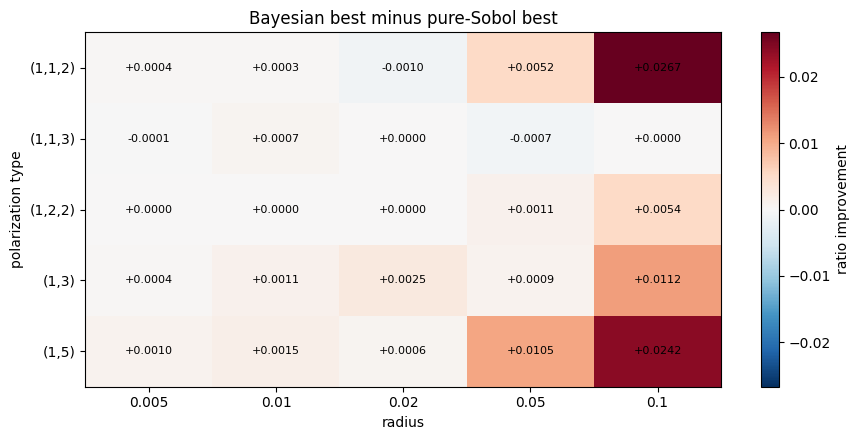

In [6]:
gain = summary.assign(gain=summary.bayesian_best_ratio-summary.sobol_best_ratio)
pivot = gain.pivot(index='type', columns='radius', values='gain')
fig, ax = plt.subplots(figsize=(9,4.5))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r', vmin=-np.abs(pivot.values).max(), vmax=np.abs(pivot.values).max())
ax.set_xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set(xlabel='radius', ylabel='polarization type', title='Bayesian best minus pure-Sobol best')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:+.4f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='ratio improvement')
fig.tight_layout()
fig.savefig(FIGURES / 'phase8_bayesian_gain.png', dpi=180, bbox_inches='tight')
plt.show()

## Example of adaptation

The type `(1,5)` search at radius 0.10 is a clear case where the GP learns a much flatter direction than the held-out Sobol arm.

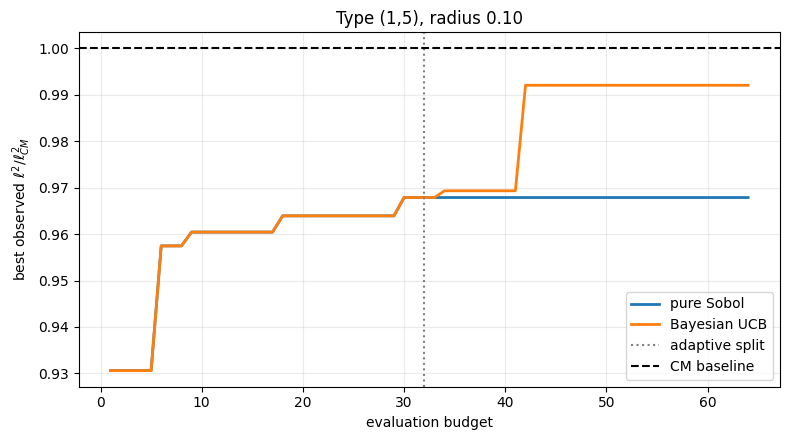

In [7]:
example = evaluations[(evaluations['type']=='(1,5)') & np.isclose(evaluations.radius, .10)]
shared = example[example.arm=='shared_sobol'].sort_values('step').ell_ratio_to_cm.tolist()
sobol = shared + example[example.arm=='sobol_holdout'].sort_values('step').ell_ratio_to_cm.tolist()
bayes = shared + example[example.arm=='bayesian_ucb'].sort_values('step').ell_ratio_to_cm.tolist()
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(np.arange(1,65), np.maximum.accumulate(sobol), label='pure Sobol', linewidth=2)
ax.plot(np.arange(1,65), np.maximum.accumulate(bayes), label='Bayesian UCB', linewidth=2)
ax.axvline(32, color='grey', linestyle=':', label='adaptive split')
ax.axhline(1, color='black', linestyle='--', label='CM baseline')
ax.set(xlabel='evaluation budget', ylabel=r'best observed $\ell^2/\ell^2_{CM}$', title='Type (1,5), radius 0.10')
ax.grid(alpha=.25); ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'phase8_example_convergence.png', dpi=180, bbox_inches='tight')
plt.show()

## Numerical checks

Every winning metric is independently passed to the 60-digit mpmath closest-vector routine. This audits the CVP result, while retaining the double-precision deformation matrix that was actually searched.

In [8]:
checks = pd.Series({
    'max radius error': summary.maximum_distance_error.max(),
    'max polarization residual': summary.maximum_polarization_residual.max(),
    'max log-volume residual': summary.maximum_log_volume_residual.max(),
    'max high-precision ell^2 discrepancy': audits.absolute_discrepancy.max(),
    'post-audit counterexamples': int(audits.counterexample_after_audit.sum()),
})
display(checks)
assert len(summary)==25 and len(evaluations)==2400 and not summary.counterexample_found.any()
assert summary.maximum_distance_error.max() < 2e-11
assert summary.maximum_polarization_residual.max() < 2e-9
assert summary.maximum_log_volume_residual.max() < 2e-9
assert audits.absolute_discrepancy.max() < 2e-12
print('All notebook checks passed.')

max radius error                        1.994794e-11
max polarization residual               2.273737e-13
max log-volume residual                 6.927792e-14
max high-precision ell^2 discrepancy    3.330669e-15
post-audit counterexamples              0.000000e+00
dtype: float64

All notebook checks passed.


## Interpretation

No tested deformation beat a CM champion. Bayesian optimization found harder directions than pure Sobol in most searches, especially at the largest radius, which strengthens the numerical evidence that these selected CM records are local peaks. It still does **not** prove local optimality: only a finite set of directions was evaluated, and a certificate would require rigorous upper bounds over the entire tangent sphere.